In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score

In [2]:
data = pd.read_csv(r"D:\Pyhton\python machine learning model xgboost - electricity demand dataset.csv")

In [3]:
data

,Timestamp,hour,dayofweek,month,year,dayofyear,Temperature,Humidity,Demand
0,01-Jan-20,0.0,2.0,1.0,2020.0,1.0,3.000000,61.288951,2457.119872
1,01-Jan-20,1.0,2.0,1.0,2020.0,1.0,3.000000,52.873702,2269.904712
2,01-Jan-20,2.0,2.0,1.0,2020.0,1.0,4.244482,36.341783,2215.640403
3,01-Jan-20,3.0,2.0,1.0,2020.0,1.0,3.000000,72.629378,2174.232413
4,01-Jan-20,4.0,2.0,1.0,2020.0,1.0,3.881208,90.582444,2472.453006
...,...,...,...,...,...,...,...,...,...
43843,31-Dec-24,19.0,1.0,12.0,2024.0,366.0,3.956838,43.287161,4689.693109
43844,31-Dec-24,20.0,1.0,12.0,2024.0,366.0,3.118824,51.705756,4331.249224
43845,31-Dec-24,21.0,1.0,12.0,2024.0,366.0,3.000000,40.565916,4015.979957
43846,31-Dec-24,22.0,1.0,12.0,2024.0,366.0,3.000000,51.998107,3353.241682


In [4]:
data.shape

(43848, 9)

In [5]:
data.head()

,Timestamp,hour,dayofweek,month,year,dayofyear,Temperature,Humidity,Demand
0,01-Jan-20,0.0,2.0,1.0,2020.0,1.0,3.000000,61.288951,2457.119872
1,01-Jan-20,1.0,2.0,1.0,2020.0,1.0,3.000000,52.873702,2269.904712
2,01-Jan-20,2.0,2.0,1.0,2020.0,1.0,4.244482,36.341783,2215.640403
3,01-Jan-20,3.0,2.0,1.0,2020.0,1.0,3.000000,72.629378,2174.232413
4,01-Jan-20,4.0,2.0,1.0,2020.0,1.0,3.881208,90.582444,2472.453006


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43848 entries, 0 to 43847
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Timestamp    43848 non-null  object 
 1   hour         43837 non-null  float64
 2   dayofweek    43839 non-null  float64
 3   month        43840 non-null  float64
 4   year         43843 non-null  float64
 5   dayofyear    43843 non-null  float64
 6   Temperature  43841 non-null  float64
 7   Humidity     43838 non-null  float64
 8   Demand       43841 non-null  float64
dtypes: float64(8), object(1)
memory usage: 3.0+ MB


In [7]:
data.isnull().sum()

Timestamp       0
hour           11
dayofweek       9
month           8
year            5
dayofyear       5
Temperature     7
Humidity       10
Demand          7
dtype: int64

In [8]:
data['Timestamp'] = pd.to_datetime(data['Timestamp'])

C:\Users\Priya Dhari Singh\AppData\Local\Temp\ipykernel_9960\652119658.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['Timestamp'] = pd.to_datetime(data['Timestamp'])


In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43848 entries, 0 to 43847
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Timestamp    43848 non-null  datetime64[ns]
 1   hour         43837 non-null  float64       
 2   dayofweek    43839 non-null  float64       
 3   month        43840 non-null  float64       
 4   year         43843 non-null  float64       
 5   dayofyear    43843 non-null  float64       
 6   Temperature  43841 non-null  float64       
 7   Humidity     43838 non-null  float64       
 8   Demand       43841 non-null  float64       
dtypes: datetime64[ns](1), float64(8)
memory usage: 3.0 MB


In [10]:
data = data.set_index('Timestamp')
data

,hour,dayofweek,month,year,dayofyear,Temperature,Humidity,Demand
Timestamp,,,,,,,,
2020-01-01,0.0,2.0,1.0,2020.0,1.0,3.000000,61.288951,2457.119872
2020-01-01,1.0,2.0,1.0,2020.0,1.0,3.000000,52.873702,2269.904712
2020-01-01,2.0,2.0,1.0,2020.0,1.0,4.244482,36.341783,2215.640403
2020-01-01,3.0,2.0,1.0,2020.0,1.0,3.000000,72.629378,2174.232413
2020-01-01,4.0,2.0,1.0,2020.0,1.0,3.881208,90.582444,2472.453006
...,...,...,...,...,...,...,...,...
2024-12-31,19.0,1.0,12.0,2024.0,366.0,3.956838,43.287161,4689.693109
2024-12-31,20.0,1.0,12.0,2024.0,366.0,3.118824,51.705756,4331.249224
2024-12-31,21.0,1.0,12.0,2024.0,366.0,3.000000,40.565916,4015.979957


In [11]:
data.isna().sum()

hour           11
dayofweek       9
month           8
year            5
dayofyear       5
Temperature     7
Humidity       10
Demand          7
dtype: int64

In [12]:
data[data.isna().any(axis=1)]

,hour,dayofweek,month,year,dayofyear,Temperature,Humidity,Demand
Timestamp,,,,,,,,
2020-04-30,NaN,3.0,4.0,2020.0,121.0,21.820261,41.353675,5393.127681
2020-07-21,NaN,1.0,7.0,2020.0,203.0,36.555833,62.779665,6248.349423
2021-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-02-27,NaN,5.0,2.0,2021.0,58.0,24.001003,53.303268,4523.253789
2021-12-13,23.0,0.0,12.0,2021.0,NaN,3.000000,75.457130,3225.225822
2021-12-14,NaN,1.0,12.0,2021.0,348.0,5.061319,47.215825,2887.848612


In [13]:
data[data.isna().all(axis = 1)]

,hour,dayofweek,month,year,dayofyear,Temperature,Humidity,Demand
Timestamp,,,,,,,,
2021-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
data = data.dropna(how = 'all')
data

,hour,dayofweek,month,year,dayofyear,Temperature,Humidity,Demand
Timestamp,,,,,,,,
2020-01-01,0.0,2.0,1.0,2020.0,1.0,3.000000,61.288951,2457.119872
2020-01-01,1.0,2.0,1.0,2020.0,1.0,3.000000,52.873702,2269.904712
2020-01-01,2.0,2.0,1.0,2020.0,1.0,4.244482,36.341783,2215.640403
2020-01-01,3.0,2.0,1.0,2020.0,1.0,3.000000,72.629378,2174.232413
2020-01-01,4.0,2.0,1.0,2020.0,1.0,3.881208,90.582444,2472.453006
...,...,...,...,...,...,...,...,...
2024-12-31,19.0,1.0,12.0,2024.0,366.0,3.956838,43.287161,4689.693109
2024-12-31,20.0,1.0,12.0,2024.0,366.0,3.118824,51.705756,4331.249224
2024-12-31,21.0,1.0,12.0,2024.0,366.0,3.000000,40.565916,4015.979957


In [15]:
data.isna().sum()

hour           7
dayofweek      5
month          4
year           1
dayofyear      1
Temperature    3
Humidity       6
Demand         3
dtype: int64

In [16]:
data[data.isna().any(axis = 1)]

,hour,dayofweek,month,year,dayofyear,Temperature,Humidity,Demand
Timestamp,,,,,,,,
2020-04-30,NaN,3.0,4.0,2020.0,121.0,21.820261,41.353675,5393.127681
2020-07-21,NaN,1.0,7.0,2020.0,203.0,36.555833,62.779665,6248.349423
2021-02-27,NaN,5.0,2.0,2021.0,58.0,24.001003,53.303268,4523.253789
2021-12-13,23.0,0.0,12.0,2021.0,NaN,3.000000,75.457130,3225.225822
2021-12-14,NaN,1.0,12.0,2021.0,348.0,5.061319,47.215825,2887.848612
2021-12-14,14.0,1.0,12.0,2021.0,348.0,15.403995,74.011557,NaN
2022-06-17,13.0,4.0,6.0,2022.0,168.0,NaN,43.171391,7196.200962
2022-06-17,NaN,4.0,6.0,2022.0,168.0,42.924693,43.645711,7605.572464
2022-06-17,17.0,4.0,NaN,2022.0,168.0,37.115634,37.554842,7696.863268


In [17]:
data[data['dayofweek'].isna()]

,hour,dayofweek,month,year,dayofyear,Temperature,Humidity,Demand
Timestamp,,,,,,,,
2022-06-17,21.0,NaN,6.0,2022.0,168.0,28.471494,54.964101,6408.288394
2023-08-31,0.0,NaN,8.0,2023.0,243.0,22.705122,81.691817,4307.378161
2024-01-28,2.0,NaN,1.0,2024.0,28.0,3.000000,68.899943,2097.117994
2024-09-24,19.0,NaN,9.0,2024.0,268.0,25.632052,74.123843,6221.030041
2024-12-18,21.0,NaN,NaN,2024.0,353.0,3.000000,64.041109,4133.304646


In [18]:
for idx in data[data['year'].isna()].index:
    print(idx)
    print(data['year'].shift(1).loc[idx])
    print(data['year'].loc[idx])
    print(data['year'].shift(-1).loc[idx])

2023-08-31 00:00:00
Timestamp
2023-08-31    2023.0
2023-08-31    2023.0
2023-08-31    2023.0
2023-08-31    2023.0
2023-08-31    2023.0
2023-08-31    2023.0
2023-08-31    2023.0
2023-08-31    2023.0
2023-08-31    2023.0
2023-08-31    2023.0
2023-08-31    2023.0
2023-08-31    2023.0
2023-08-31       NaN
2023-08-31    2023.0
2023-08-31    2023.0
2023-08-31    2023.0
2023-08-31    2023.0
2023-08-31    2023.0
2023-08-31    2023.0
2023-08-31    2023.0
2023-08-31    2023.0
2023-08-31    2023.0
2023-08-31    2023.0
2023-08-31    2023.0
Name: year, dtype: float64
Timestamp
2023-08-31    2023.0
2023-08-31    2023.0
2023-08-31    2023.0
2023-08-31    2023.0
2023-08-31    2023.0
2023-08-31    2023.0
2023-08-31    2023.0
2023-08-31    2023.0
2023-08-31    2023.0
2023-08-31    2023.0
2023-08-31    2023.0
2023-08-31       NaN
2023-08-31    2023.0
2023-08-31    2023.0
2023-08-31    2023.0
2023-08-31    2023.0
2023-08-31    2023.0
2023-08-31    2023.0
2023-08-31    2023.0
2023-08-31    2023.0
2023-08-3

In [19]:
for idx in data[data['dayofweek'].isna()].index:
    print(idx)
    print(data['dayofweek'].shift(1).loc[idx])
    print(data['dayofweek'].loc[idx])
    print(data['dayofweek'].shift(-1).loc[idx])

2022-06-17 00:00:00
Timestamp
2022-06-17    3.0
2022-06-17    4.0
2022-06-17    4.0
2022-06-17    4.0
2022-06-17    4.0
2022-06-17    4.0
2022-06-17    4.0
2022-06-17    4.0
2022-06-17    4.0
2022-06-17    4.0
2022-06-17    4.0
2022-06-17    4.0
2022-06-17    4.0
2022-06-17    4.0
2022-06-17    4.0
2022-06-17    4.0
2022-06-17    4.0
2022-06-17    4.0
2022-06-17    4.0
2022-06-17    4.0
2022-06-17    4.0
2022-06-17    4.0
2022-06-17    NaN
2022-06-17    4.0
Name: dayofweek, dtype: float64
Timestamp
2022-06-17    4.0
2022-06-17    4.0
2022-06-17    4.0
2022-06-17    4.0
2022-06-17    4.0
2022-06-17    4.0
2022-06-17    4.0
2022-06-17    4.0
2022-06-17    4.0
2022-06-17    4.0
2022-06-17    4.0
2022-06-17    4.0
2022-06-17    4.0
2022-06-17    4.0
2022-06-17    4.0
2022-06-17    4.0
2022-06-17    4.0
2022-06-17    4.0
2022-06-17    4.0
2022-06-17    4.0
2022-06-17    4.0
2022-06-17    NaN
2022-06-17    4.0
2022-06-17    4.0
Name: dayofweek, dtype: float64
Timestamp
2022-06-17    4.0
2022

In [20]:
data[['hour','dayofweek','month','year','dayofyear']]=data[['hour','dayofweek','month','year','dayofyear']].ffill()

C:\Users\Priya Dhari Singh\AppData\Local\Temp\ipykernel_9960\1955423327.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[['hour','dayofweek','month','year','dayofyear']]=data[['hour','dayofweek','month','year','dayofyear']].ffill()


In [21]:
data

,hour,dayofweek,month,year,dayofyear,Temperature,Humidity,Demand
Timestamp,,,,,,,,
2020-01-01,0.0,2.0,1.0,2020.0,1.0,3.000000,61.288951,2457.119872
2020-01-01,1.0,2.0,1.0,2020.0,1.0,3.000000,52.873702,2269.904712
2020-01-01,2.0,2.0,1.0,2020.0,1.0,4.244482,36.341783,2215.640403
2020-01-01,3.0,2.0,1.0,2020.0,1.0,3.000000,72.629378,2174.232413
2020-01-01,4.0,2.0,1.0,2020.0,1.0,3.881208,90.582444,2472.453006
...,...,...,...,...,...,...,...,...
2024-12-31,19.0,1.0,12.0,2024.0,366.0,3.956838,43.287161,4689.693109
2024-12-31,20.0,1.0,12.0,2024.0,366.0,3.118824,51.705756,4331.249224
2024-12-31,21.0,1.0,12.0,2024.0,366.0,3.000000,40.565916,4015.979957


In [22]:
data.isna().sum()

hour           0
dayofweek      0
month          0
year           0
dayofyear      0
Temperature    3
Humidity       6
Demand         3
dtype: int64

In [23]:
data[['Temperature','Humidity','Demand']]=data[['Temperature','Humidity','Demand']].bfill()

C:\Users\Priya Dhari Singh\AppData\Local\Temp\ipykernel_9960\1758165144.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[['Temperature','Humidity','Demand']]=data[['Temperature','Humidity','Demand']].bfill()


In [24]:
data.isna().sum()

hour           0
dayofweek      0
month          0
year           0
dayofyear      0
Temperature    0
Humidity       0
Demand         0
dtype: int64

In [25]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 43844 entries, 2020-01-01 to 2024-12-31
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   hour         43844 non-null  float64
 1   dayofweek    43844 non-null  float64
 2   month        43844 non-null  float64
 3   year         43844 non-null  float64
 4   dayofyear    43844 non-null  float64
 5   Temperature  43844 non-null  float64
 6   Humidity     43844 non-null  float64
 7   Demand       43844 non-null  float64
dtypes: float64(8)
memory usage: 4.0 MB


In [26]:
data[['hour','dayofweek','month','year','dayofyear']]=data[['hour','dayofweek','month','year','dayofyear']].astype(int)

C:\Users\Priya Dhari Singh\AppData\Local\Temp\ipykernel_9960\2819810516.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[['hour','dayofweek','month','year','dayofyear']]=data[['hour','dayofweek','month','year','dayofyear']].astype(int)


In [27]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 43844 entries, 2020-01-01 to 2024-12-31
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   hour         43844 non-null  int32  
 1   dayofweek    43844 non-null  int32  
 2   month        43844 non-null  int32  
 3   year         43844 non-null  int32  
 4   dayofyear    43844 non-null  int32  
 5   Temperature  43844 non-null  float64
 6   Humidity     43844 non-null  float64
 7   Demand       43844 non-null  float64
dtypes: float64(3), int32(5)
memory usage: 3.2 MB


In [28]:
# Week Number
data.insert(5,'weekofyear',data.index.isocalendar().week.astype(int))

In [29]:
data

,hour,dayofweek,month,year,dayofyear,weekofyear,Temperature,Humidity,Demand
Timestamp,,,,,,,,,
2020-01-01,0,2,1,2020,1,1,3.000000,61.288951,2457.119872
2020-01-01,1,2,1,2020,1,1,3.000000,52.873702,2269.904712
2020-01-01,2,2,1,2020,1,1,4.244482,36.341783,2215.640403
2020-01-01,3,2,1,2020,1,1,3.000000,72.629378,2174.232413
2020-01-01,4,2,1,2020,1,1,3.881208,90.582444,2472.453006
...,...,...,...,...,...,...,...,...,...
2024-12-31,19,1,12,2024,366,1,3.956838,43.287161,4689.693109
2024-12-31,20,1,12,2024,366,1,3.118824,51.705756,4331.249224
2024-12-31,21,1,12,2024,366,1,3.000000,40.565916,4015.979957


In [30]:
data.iloc[40000:40010,:]

,hour,dayofweek,month,year,dayofyear,weekofyear,Temperature,Humidity,Demand
Timestamp,,,,,,,,,
2024-07-24,20,2,7,2024,206,30,31.182180,53.269237,7022.089463
2024-07-24,21,2,7,2024,206,30,35.007867,44.350904,6794.895927
2024-07-24,22,2,7,2024,206,30,33.044240,56.575585,5813.882055
2024-07-24,23,2,7,2024,206,30,30.569828,65.939306,5352.125329
2024-07-25,0,3,7,2024,207,30,24.171043,78.679509,4592.817537
2024-07-25,1,3,7,2024,207,30,26.037271,62.386395,4291.656563
2024-07-25,2,3,7,2024,207,30,25.640074,67.959289,4255.395669
2024-07-25,3,3,7,2024,207,30,35.101776,60.233563,4506.887872
2024-07-25,4,3,7,2024,207,30,33.421603,66.702642,4725.783335


In [31]:
# Check if weekend
data.insert(7,'isweekend',data.index.dayofweek.isin([5,6]).astype(int))

In [32]:
data.head(50)

,hour,dayofweek,month,year,dayofyear,weekofyear,Temperature,isweekend,Humidity,Demand
Timestamp,,,,,,,,,,
2020-01-01,0,2,1,2020,1,1,3.000000,0,61.288951,2457.119872
2020-01-01,1,2,1,2020,1,1,3.000000,0,52.873702,2269.904712
2020-01-01,2,2,1,2020,1,1,4.244482,0,36.341783,2215.640403
2020-01-01,3,2,1,2020,1,1,3.000000,0,72.629378,2174.232413
2020-01-01,4,2,1,2020,1,1,3.881208,0,90.582444,2472.453006
2020-01-01,5,2,1,2020,1,1,10.822571,0,67.753433,3104.845505
2020-01-01,6,2,1,2020,1,1,6.306673,0,94.912591,3759.476912
2020-01-01,7,2,1,2020,1,1,7.464640,0,74.456860,4114.486001
2020-01-01,8,2,1,2020,1,1,14.746876,0,66.725005,4575.159503


In [33]:
# import holiday package
import holidays

In [34]:
import holidays

In [35]:
data['holidays']=holidays.IN(years = data.year)

C:\Users\Priya Dhari Singh\AppData\Local\Temp\ipykernel_9960\260522651.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['holidays']=holidays.IN(years = data.year)


In [36]:
data

,hour,dayofweek,month,year,dayofyear,weekofyear,Temperature,isweekend,Humidity,Demand,holidays
Timestamp,,,,,,,,,,,
2020-01-01,0,2,1,2020,1,1,3.000000,0,61.288951,2457.119872,NaN
2020-01-01,1,2,1,2020,1,1,3.000000,0,52.873702,2269.904712,NaN
2020-01-01,2,2,1,2020,1,1,4.244482,0,36.341783,2215.640403,NaN
2020-01-01,3,2,1,2020,1,1,3.000000,0,72.629378,2174.232413,NaN
2020-01-01,4,2,1,2020,1,1,3.881208,0,90.582444,2472.453006,NaN
...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31,19,1,12,2024,366,1,3.956838,0,43.287161,4689.693109,NaN
2024-12-31,20,1,12,2024,366,1,3.118824,0,51.705756,4331.249224,NaN
2024-12-31,21,1,12,2024,366,1,3.000000,0,40.565916,4015.979957,NaN


In [37]:
data = data.drop('holidays',axis = 1)

In [38]:
data

,hour,dayofweek,month,year,dayofyear,weekofyear,Temperature,isweekend,Humidity,Demand
Timestamp,,,,,,,,,,
2020-01-01,0,2,1,2020,1,1,3.000000,0,61.288951,2457.119872
2020-01-01,1,2,1,2020,1,1,3.000000,0,52.873702,2269.904712
2020-01-01,2,2,1,2020,1,1,4.244482,0,36.341783,2215.640403
2020-01-01,3,2,1,2020,1,1,3.000000,0,72.629378,2174.232413
2020-01-01,4,2,1,2020,1,1,3.881208,0,90.582444,2472.453006
...,...,...,...,...,...,...,...,...,...,...
2024-12-31,19,1,12,2024,366,1,3.956838,0,43.287161,4689.693109
2024-12-31,20,1,12,2024,366,1,3.118824,0,51.705756,4331.249224
2024-12-31,21,1,12,2024,366,1,3.000000,0,40.565916,4015.979957


In [39]:
# lagged Features
data['Demand_lag_24hr']=data['Demand'].shift(24)
data

,hour,dayofweek,month,year,dayofyear,weekofyear,Temperature,isweekend,Humidity,Demand,Demand_lag_24hr
Timestamp,,,,,,,,,,,
2020-01-01,0,2,1,2020,1,1,3.000000,0,61.288951,2457.119872,NaN
2020-01-01,1,2,1,2020,1,1,3.000000,0,52.873702,2269.904712,NaN
2020-01-01,2,2,1,2020,1,1,4.244482,0,36.341783,2215.640403,NaN
2020-01-01,3,2,1,2020,1,1,3.000000,0,72.629378,2174.232413,NaN
2020-01-01,4,2,1,2020,1,1,3.881208,0,90.582444,2472.453006,NaN
...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31,19,1,12,2024,366,1,3.956838,0,43.287161,4689.693109,5102.077310
2024-12-31,20,1,12,2024,366,1,3.118824,0,51.705756,4331.249224,4187.844204
2024-12-31,21,1,12,2024,366,1,3.000000,0,40.565916,4015.979957,3859.260701


In [40]:
data['Demand_lag_168hr']=data['Demand'].shift(168)

In [41]:
data

,hour,dayofweek,month,year,dayofyear,weekofyear,Temperature,isweekend,Humidity,Demand,Demand_lag_24hr,Demand_lag_168hr
Timestamp,,,,,,,,,,,,
2020-01-01,0,2,1,2020,1,1,3.000000,0,61.288951,2457.119872,NaN,NaN
2020-01-01,1,2,1,2020,1,1,3.000000,0,52.873702,2269.904712,NaN,NaN
2020-01-01,2,2,1,2020,1,1,4.244482,0,36.341783,2215.640403,NaN,NaN
2020-01-01,3,2,1,2020,1,1,3.000000,0,72.629378,2174.232413,NaN,NaN
2020-01-01,4,2,1,2020,1,1,3.881208,0,90.582444,2472.453006,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31,19,1,12,2024,366,1,3.956838,0,43.287161,4689.693109,5102.077310,5105.730509
2024-12-31,20,1,12,2024,366,1,3.118824,0,51.705756,4331.249224,4187.844204,4673.672173
2024-12-31,21,1,12,2024,366,1,3.000000,0,40.565916,4015.979957,3859.260701,3856.359014


In [42]:
# Rolling mean and rolling standard deviation
data['demand_rolling_mean_24hr']=data['Demand'].rolling(window=24).mean()


In [43]:
data['demand_rolling_std_24hr']=data['Demand'].rolling(window=24).std()

In [44]:
# Dropping null values
data = data.dropna()

In [45]:
data

,hour,dayofweek,month,year,dayofyear,weekofyear,Temperature,isweekend,Humidity,Demand,Demand_lag_24hr,Demand_lag_168hr,demand_rolling_mean_24hr,demand_rolling_std_24hr
Timestamp,,,,,,,,,,,,,,
2020-01-08,0,2,1,2020,8,2,3.000000,0,47.891592,2363.060115,2216.875986,2457.119872,3857.890516,1007.130968
2020-01-08,1,2,1,2020,8,2,4.433666,0,61.209727,2282.558766,2400.102433,2269.904712,3852.992863,1014.785101
2020-01-08,2,2,1,2020,8,2,5.000529,0,63.868618,2193.324174,2493.107375,2215.640403,3840.501897,1033.916351
2020-01-08,3,2,1,2020,8,2,4.253477,0,44.603210,2208.724679,2241.451559,2174.232413,3839.138277,1036.136212
2020-01-08,4,2,1,2020,8,2,5.966044,0,85.921008,2402.611018,2406.161001,2472.453006,3838.990361,1036.349905
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31,19,1,12,2024,366,1,3.956838,0,43.287161,4689.693109,5102.077310,5105.730509,4039.969992,976.961312
2024-12-31,20,1,12,2024,366,1,3.118824,0,51.705756,4331.249224,4187.844204,4673.672173,4045.945201,978.342615
2024-12-31,21,1,12,2024,366,1,3.000000,0,40.565916,4015.979957,3859.260701,3856.359014,4052.475170,977.565114


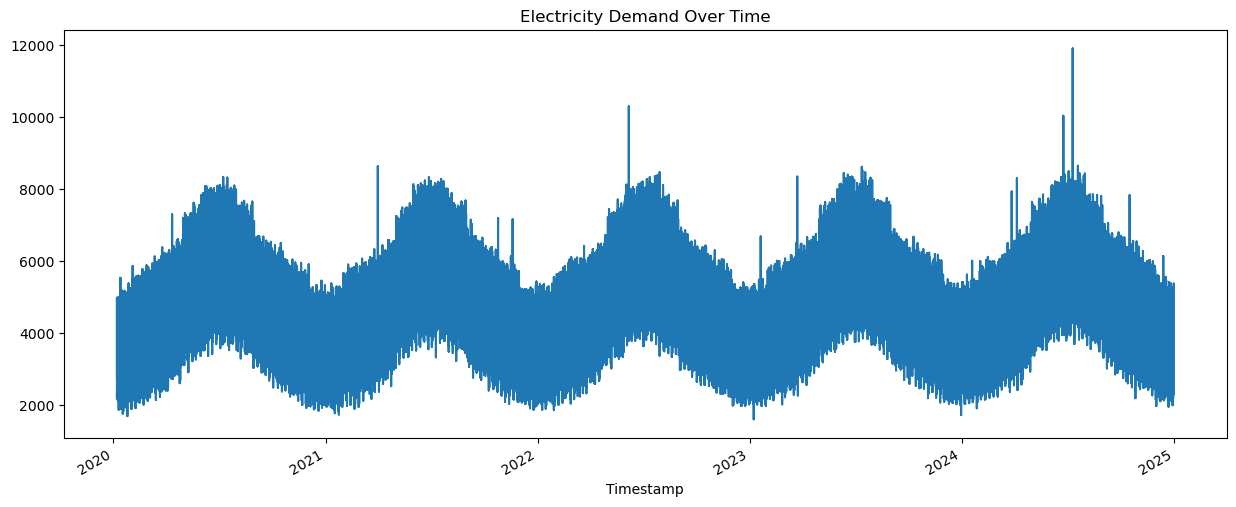

In [46]:
# Plotting row demand
data['Demand'].plot(figsize = (15,6),title = 'Electricity Demand Over Time')
plt.show()

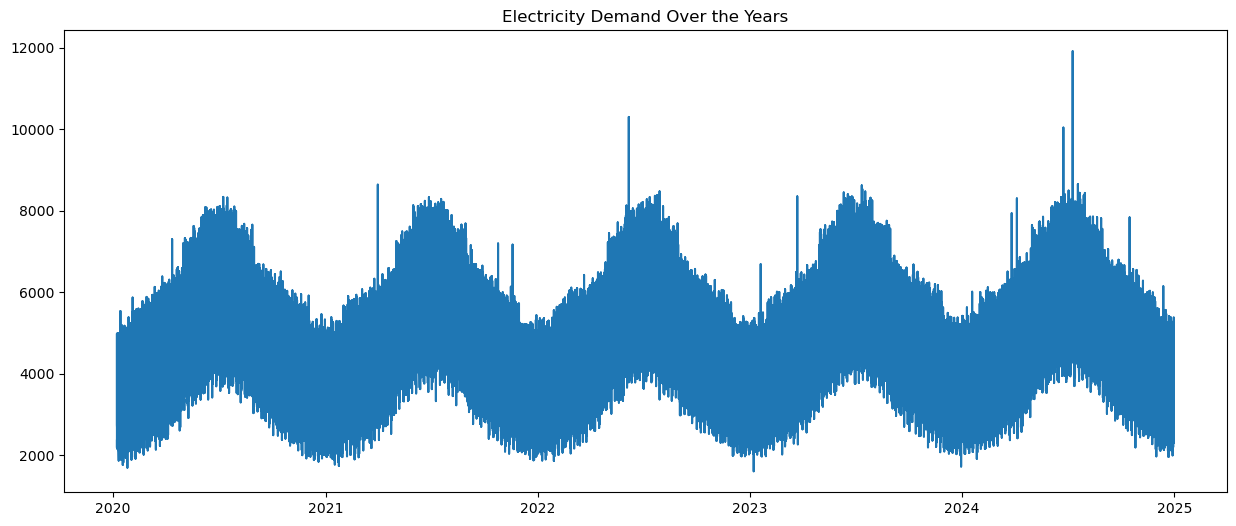

In [47]:
plt.figure(figsize=(15,6))
plt.plot(data['Demand'])
plt.title('Electricity Demand Over the Years')
plt.show()

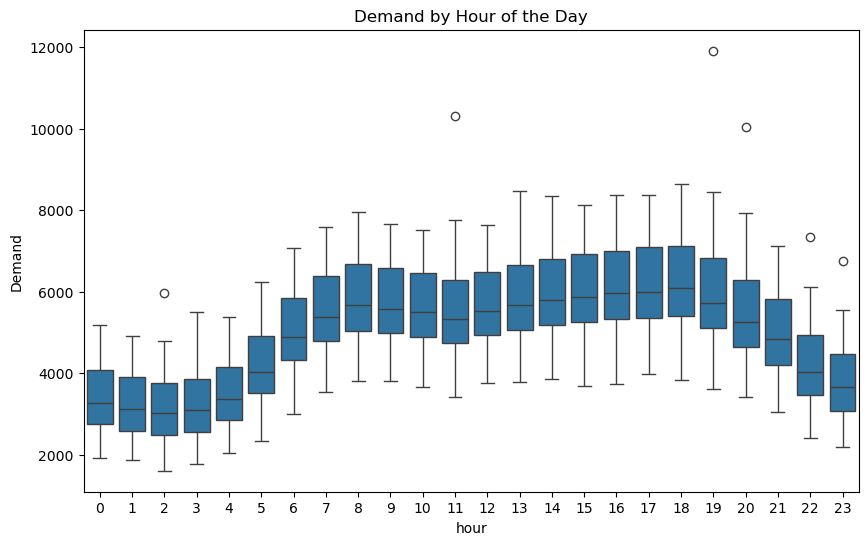

In [48]:
plt.figure(figsize=(10,6))
sns.boxplot(data=data, x='hour',y='Demand')
plt.title('Demand by Hour of the Day')
plt.show()

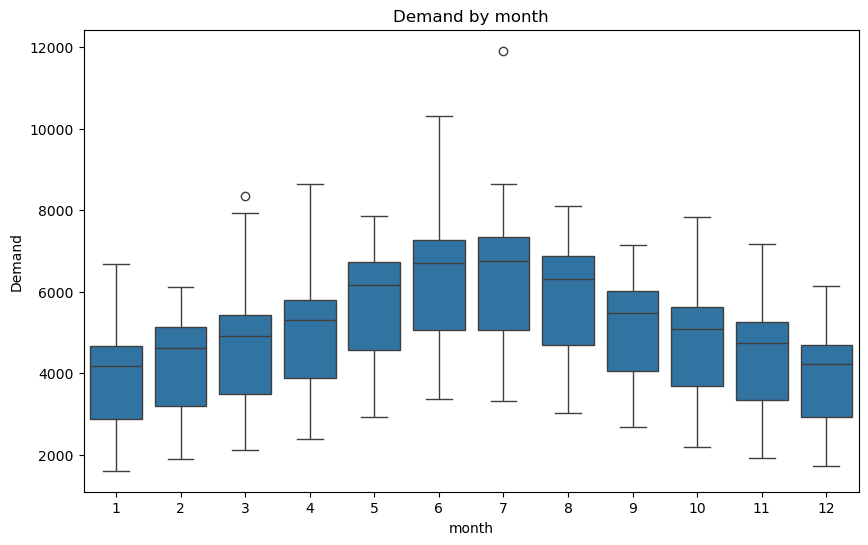

In [49]:
plt.figure(figsize=(10,6))
sns.boxplot(data, x='month',y='Demand')
plt.title('Demand by month')
plt.show()

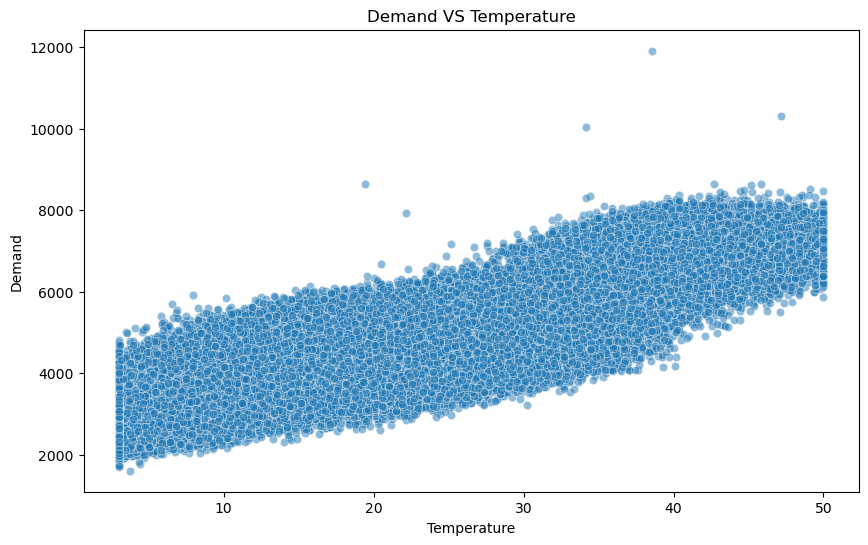

In [50]:
plt.figure(figsize=(10,6))
sns.scatterplot(data,x='Temperature',y='Demand',alpha=0.5)
plt.title('Demand VS Temperature')
plt.show()

<Axes: >

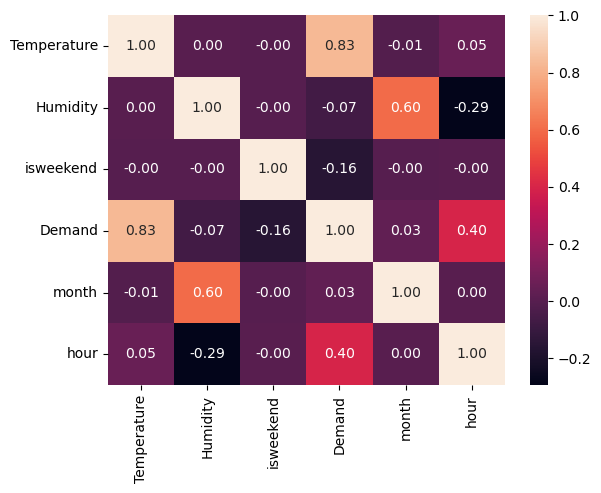

In [51]:
sns.heatmap(data[['Temperature','Humidity','isweekend','Demand','month','hour']].corr(),annot=True,fmt='.2f')

In [52]:
# Forecasting
Y=data.Demand
X=data.drop('Demand',axis=1)

In [53]:
print(Y)
print(X)

Timestamp
2020-01-08    2363.060115
2020-01-08    2282.558766
2020-01-08    2193.324174
2020-01-08    2208.724679
2020-01-08    2402.611018
                 ...     
2024-12-31    4689.693109
2024-12-31    4331.249224
2024-12-31    4015.979957
2024-12-31    3353.241682
2024-12-31    3219.023339
Name: Demand, Length: 43676, dtype: float64
            hour  dayofweek  month  year  dayofyear  weekofyear  Temperature  \
Timestamp                                                                      
2020-01-08     0          2      1  2020          8           2     3.000000   
2020-01-08     1          2      1  2020          8           2     4.433666   
2020-01-08     2          2      1  2020          8           2     5.000529   
2020-01-08     3          2      1  2020          8           2     4.253477   
2020-01-08     4          2      1  2020          8           2     5.966044   
...          ...        ...    ...   ...        ...         ...          ...   
2024-12-31    19    

In [54]:
# Training Data and Testing Data
X_train = X.loc[ : '2023-12-31']
X_train

,hour,dayofweek,month,year,dayofyear,weekofyear,Temperature,isweekend,Humidity,Demand_lag_24hr,Demand_lag_168hr,demand_rolling_mean_24hr,demand_rolling_std_24hr
Timestamp,,,,,,,,,,,,,
2020-01-08,0,2,1,2020,8,2,3.000000,0,47.891592,2216.875986,2457.119872,3857.890516,1007.130968
2020-01-08,1,2,1,2020,8,2,4.433666,0,61.209727,2400.102433,2269.904712,3852.992863,1014.785101
2020-01-08,2,2,1,2020,8,2,5.000529,0,63.868618,2493.107375,2215.640403,3840.501897,1033.916351
2020-01-08,3,2,1,2020,8,2,4.253477,0,44.603210,2241.451559,2174.232413,3839.138277,1036.136212
2020-01-08,4,2,1,2020,8,2,5.966044,0,85.921008,2406.161001,2472.453006,3838.990361,1036.349905
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-31,19,6,12,2023,365,52,6.721774,1,46.627264,3894.908251,3840.654680,3597.790591,879.089476
2023-12-31,20,6,12,2023,365,52,7.557696,1,58.505012,3797.287793,4122.218903,3599.126925,879.430235
2023-12-31,21,6,12,2023,365,52,3.000000,1,48.001079,3280.602315,3307.887152,3604.785551,877.726873


In [55]:
Y_train=Y.loc[:'2023-12-31']
Y_train

Timestamp
2020-01-08    2363.060115
2020-01-08    2282.558766
2020-01-08    2193.324174
2020-01-08    2208.724679
2020-01-08    2402.611018
                 ...     
2023-12-31    4185.721624
2023-12-31    3829.359810
2023-12-31    3416.409325
2023-12-31    3188.143951
2023-12-31    2631.860751
Name: Demand, Length: 34892, dtype: float64

In [56]:
X_test = X.loc['2024-01-01':]
X_test

,hour,dayofweek,month,year,dayofyear,weekofyear,Temperature,isweekend,Humidity,Demand_lag_24hr,Demand_lag_168hr,demand_rolling_mean_24hr,demand_rolling_std_24hr
Timestamp,,,,,,,,,,,,,
2024-01-01,0,0,1,2024,1,1,3.000000,0,65.297046,2373.967493,2752.003113,3626.185642,856.204515
2024-01-01,1,0,1,2024,1,1,3.000000,0,69.068654,2328.972904,2419.747602,3640.380403,836.357296
2024-01-01,2,0,1,2024,1,1,3.000000,0,80.885372,1729.176090,2292.834087,3669.813854,776.458065
2024-01-01,3,0,1,2024,1,1,7.788675,0,66.501527,2257.337352,2507.704476,3685.801618,749.595470
2024-01-01,4,0,1,2024,1,1,6.607828,0,57.858109,2516.948873,2690.933257,3692.926651,738.736316
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31,19,1,12,2024,366,1,3.956838,0,43.287161,5102.077310,5105.730509,4039.969992,976.961312
2024-12-31,20,1,12,2024,366,1,3.118824,0,51.705756,4187.844204,4673.672173,4045.945201,978.342615
2024-12-31,21,1,12,2024,366,1,3.000000,0,40.565916,3859.260701,3856.359014,4052.475170,977.565114


In [57]:
Y_test = Y.loc['2024-01-01':]
Y_test

Timestamp
2024-01-01    2720.606072
2024-01-01    2669.647167
2024-01-01    2435.578924
2024-01-01    2641.043699
2024-01-01    2687.949643
                 ...     
2024-12-31    4689.693109
2024-12-31    4331.249224
2024-12-31    4015.979957
2024-12-31    3353.241682
2024-12-31    3219.023339
Name: Demand, Length: 8784, dtype: float64

In [58]:
print(X_test.shape)
print(Y_test.shape)
print(X_train.shape)
print(Y_train.shape)

(8784, 13)
(8784,)
(34892, 13)
(34892,)


In [59]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error,mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit

In [60]:
# Instialize and train the model
model_xgb = XGBRegressor(n_estimators = 1000,
                         early_stopping_rounds = 50,
                        learning_rate = 0.01,
                        random_state = 42,
                         objective='reg:squarederror')

In [61]:
model_xgb.fit(X_train,Y_train,
             eval_set=[(X_train,Y_train),(X_test,Y_test)],verbose= False)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=50,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

In [62]:
## Prediction

predictions_xgb = model_xgb.predict(X_test)

In [65]:
Y_test

Timestamp
2024-01-01    2720.606072
2024-01-01    2669.647167
2024-01-01    2435.578924
2024-01-01    2641.043699
2024-01-01    2687.949643
                 ...     
2024-12-31    4689.693109
2024-12-31    4331.249224
2024-12-31    4015.979957
2024-12-31    3353.241682
2024-12-31    3219.023339
Name: Demand, Length: 8784, dtype: float64

In [66]:
predictions_xgb

array([2661.1345, 2490.7568, 2397.6526, ..., 3720.9294, 3267.4285,
       3226.3162], dtype=float32)

In [68]:
from sklearn.metrics import r2_score
r2_score(Y_test, predictions_xgb)

0.9848351580902333

In [ ]:
rmse_xgb = np.sqrt(mean_squared_error(Y_test,predictions_xgb))
mean_xgb = mean_absolute_error(Y_test,predictions_xgb)

In [ ]:
print(rmse_xgb)
print(mean_xgb)

In [ ]:
plt.figure(figsize=(15,6))
plt.plot(Y_test.index,Y_test,
        label = 'Actual Demand',
        color = 'Blue')
plt.plot(Y_test.index,predictions_xgb,
        label = 'XGBoost Predicted Values',
        color = 'red')
plt.title('XGBoost Electricity Prediction')
plt.xlabel('Date')
plt.ylabel('Demand')
plt.legend()
plt.show()